# Visualize samples across data domains

This notebook shows a few sample time series from the `energy` and `transport` domains using the prepared Arrow files in `data/`.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from gluonts.dataset.arrow import File

plt.style.use("default")

In [ ]:
DATA_DIR = Path("../data")
DOMAINS = ["energy", "transport"]


def load_domain_train_rows(domain: str):
    path = DATA_DIR / f"{domain}_train.arrow"
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path.resolve()}")
    return list(File.infer(path))


domain_rows = {domain: load_domain_train_rows(domain) for domain in DOMAINS}
{domain: len(rows) for domain, rows in domain_rows.items()}

{'energy': 5871, 'transport': 1124}

In [ ]:
summary = []
for domain, rows in domain_rows.items():
    lengths = [len(np.asarray(r["target"], dtype=np.float32)) for r in rows]
    datasets = sorted({r.get("dataset", "unknown") for r in rows})
    summary.append(
        {
            "domain": domain,
            "num_series": len(rows),
            "min_length": int(np.min(lengths)),
            "median_length": int(np.median(lengths)),
            "max_length": int(np.max(lengths)),
            "num_source_datasets": len(datasets),
        }
    )

pd.DataFrame(summary)

,domain,num_series,min_length,median_length,max_length,num_source_datasets
0,energy,5871,3271,8440,139936,3
1,transport,1124,4024,17224,17224,2


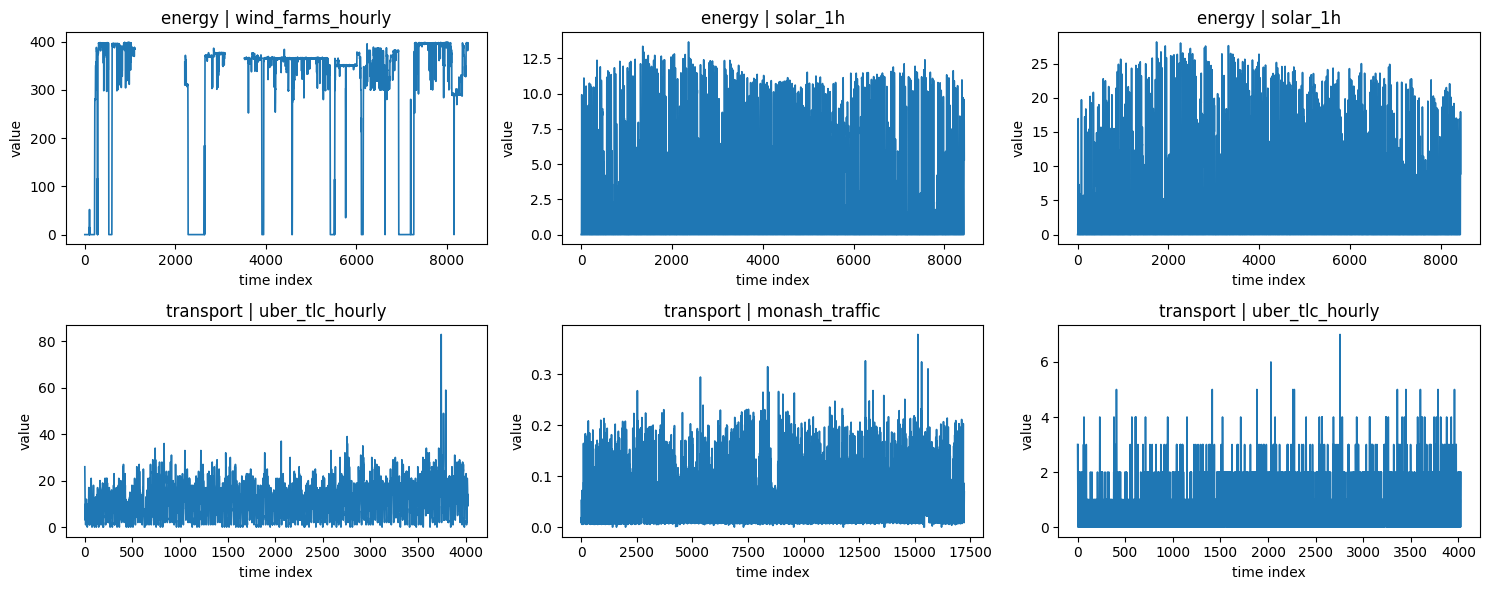

In [ ]:
num_samples_per_domain = 3
rng = np.random.default_rng(7)

fig, axes = plt.subplots(
    len(DOMAINS), num_samples_per_domain, figsize=(15, 6), squeeze=False
)

for row_idx, domain in enumerate(DOMAINS):
    rows = domain_rows[domain]
    sample_indices = rng.choice(len(rows), size=num_samples_per_domain, replace=False)

    for col_idx, sample_idx in enumerate(sample_indices):
        row = rows[int(sample_idx)]
        target = np.asarray(row["target"], dtype=np.float32)
        dataset_name = row.get("dataset", "unknown")

        ax = axes[row_idx, col_idx]
        ax.plot(target, linewidth=1.2)
        ax.set_title(f"{domain} | {dataset_name}")
        ax.set_xlabel("time index")
        ax.set_ylabel("value")

fig.tight_layout()
plt.show()

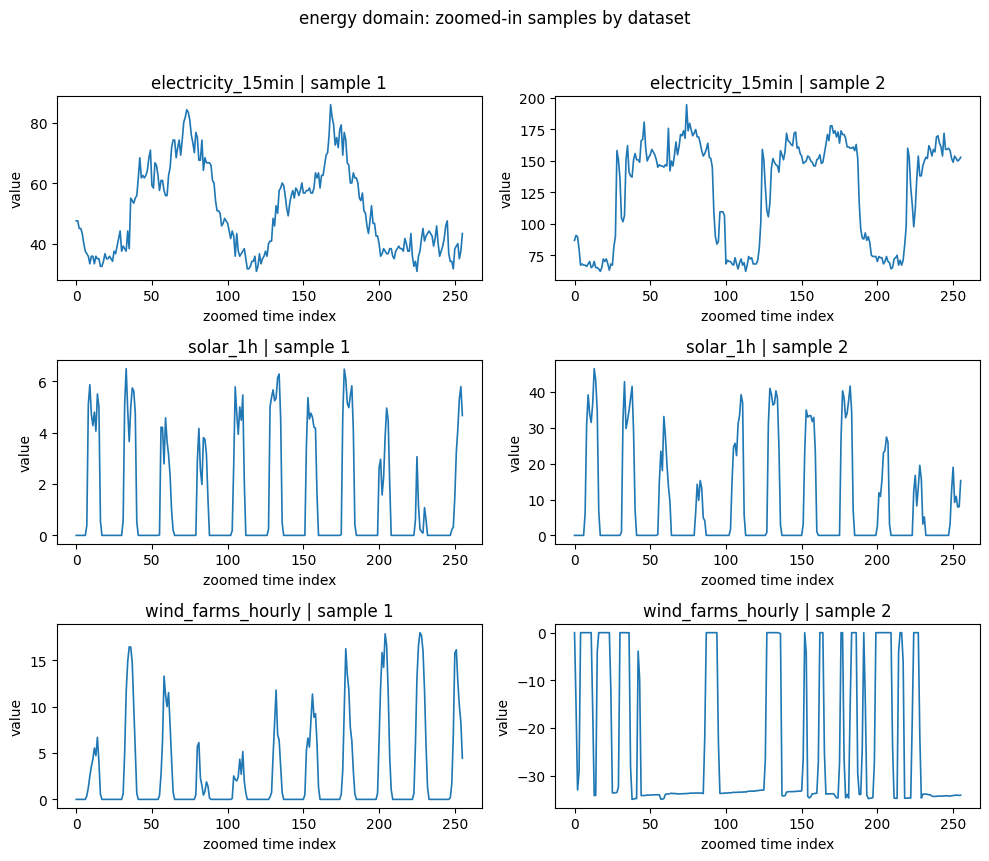

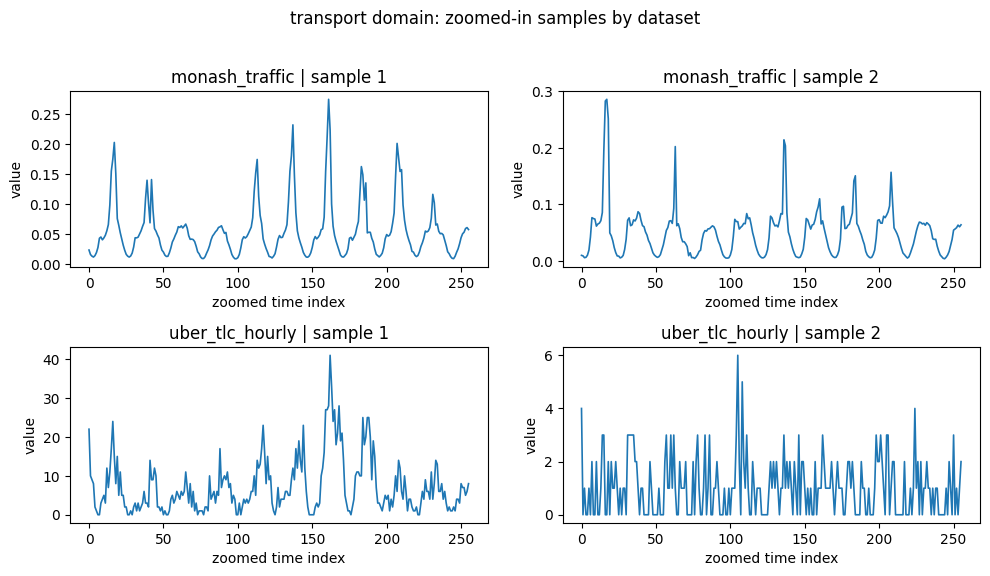

In [ ]:
zoom_points = 256
samples_per_dataset = 2
rng_zoom = np.random.default_rng(42)

for domain in DOMAINS:
    rows = domain_rows[domain]
    dataset_names = sorted({row.get("dataset", "unknown") for row in rows})

    fig, axes = plt.subplots(
        len(dataset_names),
        samples_per_dataset,
        figsize=(5 * samples_per_dataset, 2.8 * len(dataset_names)),
        squeeze=False,
    )

    for dataset_row, dataset_name in enumerate(dataset_names):
        dataset_rows = [
            row for row in rows if row.get("dataset", "unknown") == dataset_name
        ]

        n = min(samples_per_dataset, len(dataset_rows))
        chosen = rng_zoom.choice(len(dataset_rows), size=n, replace=False)

        for col in range(samples_per_dataset):
            ax = axes[dataset_row, col]

            if col >= n:
                ax.axis("off")
                continue

            target = np.asarray(
                dataset_rows[int(chosen[col])]["target"], dtype=np.float32
            )
            tail = target[-zoom_points:]

            ax.plot(tail, linewidth=1.2)
            ax.set_title(f"{dataset_name} | sample {col + 1}")
            ax.set_xlabel("zoomed time index")
            ax.set_ylabel("value")

    fig.suptitle(f"{domain} domain: zoomed-in samples by dataset", y=1.02)
    fig.tight_layout()
    plt.show()

In [ ]:
stats_rows = []

for domain, rows in domain_rows.items():
    dataset_names = sorted({row.get("dataset", "unknown") for row in rows})

    for dataset_name in dataset_names:
        dataset_rows = [r for r in rows if r.get("dataset", "unknown") == dataset_name]
        lengths = np.asarray(
            [len(np.asarray(r["target"], dtype=np.float32)) for r in dataset_rows],
            dtype=np.int32,
        )

        stats_rows.append(
            {
                "domain": domain,
                "dataset": dataset_name,
                "num_series": int(len(dataset_rows)),
                "total_time_points": int(lengths.sum()),
                "min_time_points": int(lengths.min()),
                "p25_time_points": float(np.percentile(lengths, 25)),
                "median_time_points": float(np.median(lengths)),
                "mean_time_points": float(lengths.mean()),
                "p75_time_points": float(np.percentile(lengths, 75)),
                "max_time_points": int(lengths.max()),
            }
        )

stats_df = (
    pd.DataFrame(stats_rows).sort_values(["domain", "dataset"]).reset_index(drop=True)
)
stats_df

,domain,dataset,num_series,total_time_points,min_time_points,p25_time_points,median_time_points,mean_time_points,p75_time_points,max_time_points
0,energy,electricity_15min,370,41818058,15712,104896.0,104896.0,113021.778378,139936.0,139936
1,energy,solar_1h,5166,43601040,8440,8440.0,8440.0,8440.000000,8440.0,8440
2,energy,wind_farms_hourly,335,2758784,3271,8464.0,8464.0,8235.176119,8464.0,8464
3,transport,monash_traffic,862,14847088,17224,17224.0,17224.0,17224.000000,17224.0,17224
4,transport,uber_tlc_hourly,262,1054288,4024,4024.0,4024.0,4024.000000,4024.0,4024
